# 04 · Pase y posesión 2 contra 1

Dos atacantes intentan mantener el balón frente a un defensor. Este cuaderno implementa el entorno simplificado proporcionado y compara cuatro algoritmos tabulares. La portería solo aparece como referencia en las figuras: **no existe una acción ni una recompensa por gol** en este entorno.


In [18]:
import copy
import math
import time
from collections import Counter, defaultdict

import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np
import pandas as pd
from IPython.display import clear_output, display

np.random.seed(42)

## 1. Formulación del MDP y entorno

- **Estado observado:** distancia y ángulo del balón, del compañero y del defensor, medidos desde el atacante que porta el balón. Cada distancia tiene 4 zonas y cada ángulo 5 sectores: hasta $4\times5\times4\times5\times4\times5=40\,000$ tuplas y $280\,000$ pares estado-acción con 7 acciones. Se almacena solo lo visitado.
- **Acciones:** tres potencias de pase al compañero, drible, giro $+35^\circ$, giro $-35^\circ$ y despeje.
- **Transición:** el balón conserva parte de su velocidad, el defensor se acerca con ruido y un pase completado cambia al portador.
- **Recompensa:** $+30$ por pase completado durante el episodio, $+0.2$ al conservar el balón cerca del portador, $-30$ por intercepción, $-10$ por salida y $+100$ por cumplir la tarea.
- **Fin y éxito:** el episodio termina por intercepción, salida, éxito o límite de 100 pasos. El código adjunto define éxito como **al menos 50 pasos y 3 pases completados**.
- **Descuento:** $\gamma=0.99$ en el entrenamiento.

Es una aproximación del MDP: los contadores de pasos y pases y la velocidad del balón influyen en la transición o en el fin, pero no forman parte de la tupla observada. Se conserva el entorno tal como fue proporcionado.


In [19]:
class PassingPossessionSimEnv:
    """
    Entorno simplificado para Cooperación 2 vs 1 / Passing-Possession.

    Estado:
        (
            ball_dist_bin,
            ball_angle_bin,
            teammate_dist_bin,
            teammate_angle_bin,
            defender_dist_bin,
            defender_angle_bin,
        )

    Acciones:
        0 -> PASS suave   (KICK 40 hacia compañero)
        1 -> PASS medio   (KICK 65 hacia compañero)
        2 -> PASS fuerte  (KICK 90 hacia compañero)
        3 -> DRIBBLE      (KICK 25 adelante + avance)
        4 -> TURN +35
        5 -> TURN -35
        6 -> CLEAR        (KICK 100 adelante)

    Éxito:
        posesión >= 50 pasos y >= 3 pases completados.
    """

    def __init__(
        self,
        max_steps=100,
        control_threshold=0.8,
        interception_radius=1.0,
    ):
        self.max_steps = max_steps
        self.control_threshold = control_threshold
        self.interception_radius = interception_radius

        self.pass_powers = [40.0, 65.0, 90.0]

        self.reset()

    # ============================================================
    # RESET
    # ============================================================

    def reset(self):

        # Atacante 1
        self.attackers = [
            {
                "x": -15.0,
                "y": -6.0,
                "theta": 0.0,
            },
            {
                "x": -15.0,
                "y": 6.0,
                "theta": 0.0,
            },
        ]

        # Atacante inicialmente con posesión
        self.carrier = 0

        # Defensor colocado entre ambos atacantes
        self.defender_x = np.random.uniform(-8.0, -3.0)
        self.defender_y = np.random.uniform(-3.0, 3.0)

        # Balón cerca del atacante con posesión
        carrier = self.attackers[self.carrier]

        self.ball_x = carrier["x"] + 0.5
        self.ball_y = carrier["y"]

        self.ball_vx = 0.0
        self.ball_vy = 0.0

        self.steps = 0
        self.completed_passes = 0

        self.ball_trajectory_x = [self.ball_x]
        self.ball_trajectory_y = [self.ball_y]

        return self._get_state()

    # ============================================================
    # GEOMETRÍA
    # ============================================================

    def _relative_polar(self, origin, object_x, object_y):

        dx = object_x - origin["x"]
        dy = object_y - origin["y"]

        dist = math.hypot(dx, dy)

        global_angle = math.degrees(math.atan2(dy, dx))

        relative_angle = (global_angle - origin["theta"] + 180.0) % 360.0 - 180.0

        return dist, relative_angle

    def _current_players(self):

        carrier = self.attackers[self.carrier]
        teammate = self.attackers[1 - self.carrier]

        return carrier, teammate

    # ============================================================
    # OBSERVACIÓN
    # ============================================================

    def _get_obs(self):

        carrier, teammate = self._current_players()

        # Balón respecto al jugador con posesión
        d_ball, angle_ball = self._relative_polar(
            carrier,
            self.ball_x,
            self.ball_y,
        )

        # Compañero
        d_comp, angle_comp = self._relative_polar(
            carrier,
            teammate["x"],
            teammate["y"],
        )

        # Defensor
        d_def, angle_def = self._relative_polar(
            carrier,
            self.defender_x,
            self.defender_y,
        )

        return (
            d_ball,
            angle_ball,
            d_comp,
            angle_comp,
            d_def,
            angle_def,
        )

    # ============================================================
    # DISCRETIZACIÓN
    # ============================================================

    def _distance_ball_bin(self, d):

        if d <= 0.8:
            return 0

        elif d < 2.0:
            return 1

        elif d < 4.0:
            return 2

        else:
            return 3

    def _distance_player_bin(self, d):

        if d < 5.0:
            return 0

        elif d < 10.0:
            return 1

        elif d < 20.0:
            return 2

        else:
            return 3

    def _angle_bin(self, angle):

        if abs(angle) <= 15.0:
            return 0  # frente

        elif -60.0 <= angle < -15.0:
            return 1  # derecha

        elif 15.0 < angle <= 60.0:
            return 2  # izquierda

        elif angle < -60.0:
            return 3  # atrás-derecha

        else:
            return 4  # atrás-izquierda

    def _discretize(
        self,
        d_ball,
        angle_ball,
        d_comp,
        angle_comp,
        d_def,
        angle_def,
    ):

        return (
            self._distance_ball_bin(d_ball),
            self._angle_bin(angle_ball),
            self._distance_player_bin(d_comp),
            self._angle_bin(angle_comp),
            self._distance_player_bin(d_def),
            self._angle_bin(angle_def),
        )

    def _get_state(self):

        return self._discretize(*self._get_obs())

    # ============================================================
    # PASAR AL COMPAÑERO
    # ============================================================

    def _pass_to_teammate(self, power):

        carrier, teammate = self._current_players()

        dx = teammate["x"] - self.ball_x
        dy = teammate["y"] - self.ball_y

        dist = math.hypot(dx, dy)

        if dist == 0:
            return

        # Dirección exacta del compañero
        ux = dx / dist
        uy = dy / dist

        # Simplificación del efecto de KICK
        speed = power * 0.025

        self.ball_vx = speed * ux
        self.ball_vy = speed * uy

    # ============================================================
    # DRIBBLE
    # ============================================================

    def _dribble(self):

        carrier, _ = self._current_players()

        rad = math.radians(carrier["theta"])

        # KICK 25 hacia delante
        kick_speed = 25.0 * 0.025

        self.ball_vx = kick_speed * math.cos(rad)
        self.ball_vy = kick_speed * math.sin(rad)

        # Carrera corta del jugador
        carrier["x"] += 0.5 * math.cos(rad)
        carrier["y"] += 0.5 * math.sin(rad)

    # ============================================================
    # TURN
    # ============================================================

    def _turn(self, angle):

        carrier, _ = self._current_players()

        carrier["theta"] = (carrier["theta"] + angle + 180.0) % 360.0 - 180.0

    # ============================================================
    # DESPEJE
    # ============================================================

    def _clear(self):

        carrier, _ = self._current_players()

        rad = math.radians(carrier["theta"])

        speed = 100.0 * 0.025

        self.ball_vx = speed * math.cos(rad)
        self.ball_vy = speed * math.sin(rad)

    # ============================================================
    # MOVIMIENTO DEL DEFENSOR
    # ============================================================

    def _move_defender(self):

        # Defensor intenta acercarse al balón
        dx = self.ball_x - self.defender_x
        dy = self.ball_y - self.defender_y

        dist = math.hypot(dx, dy)

        if dist > 0:

            speed = 0.35

            # pequeño componente estocástico
            noise_x = np.random.uniform(-0.05, 0.05)
            noise_y = np.random.uniform(-0.05, 0.05)

            self.defender_x += speed * dx / dist + noise_x

            self.defender_y += speed * dy / dist + noise_y

    # ============================================================
    # STEP
    # ============================================================

    def step(self, action):

        self.steps += 1

        # --------------------------------------------------------
        # Ejecutar macro-acción
        # --------------------------------------------------------

        if action == 0:
            self._pass_to_teammate(40)

        elif action == 1:
            self._pass_to_teammate(65)

        elif action == 2:
            self._pass_to_teammate(90)

        elif action == 3:
            self._dribble()

        elif action == 4:
            self._turn(+35)

        elif action == 5:
            self._turn(-35)

        elif action == 6:
            self._clear()

        else:
            raise ValueError("Acción inválida")

        # --------------------------------------------------------
        # Actualizar balón
        # --------------------------------------------------------

        self.ball_x += self.ball_vx
        self.ball_y += self.ball_vy

        # Inercia
        self.ball_vx *= 0.94
        self.ball_vy *= 0.94

        # --------------------------------------------------------
        # Mover defensor
        # --------------------------------------------------------

        self._move_defender()

        # --------------------------------------------------------
        # Comprobar intercepción
        # --------------------------------------------------------

        d_def_ball = math.hypot(
            self.ball_x - self.defender_x,
            self.ball_y - self.defender_y,
        )

        intercepted = d_def_ball <= self.interception_radius

        # --------------------------------------------------------
        # Comprobar pase completado
        # --------------------------------------------------------

        carrier, teammate = self._current_players()

        d_teammate_ball = math.hypot(
            self.ball_x - teammate["x"],
            self.ball_y - teammate["y"],
        )

        pass_completed = False

        if (
            action in [0, 1, 2]
            and d_teammate_ball <= self.control_threshold
            and not intercepted
        ):

            pass_completed = True
            self.completed_passes += 1

            # El compañero pasa a ser quien tiene posesión
            self.carrier = 1 - self.carrier

            # Frenamos el balón al recibirlo
            self.ball_vx = 0.0
            self.ball_vy = 0.0

        # --------------------------------------------------------
        # Fuera del campo
        # --------------------------------------------------------

        ball_out = abs(self.ball_x) > 52.5 or abs(self.ball_y) > 34.0

        # --------------------------------------------------------
        # Éxito
        # --------------------------------------------------------

        success = self.steps >= 50 and self.completed_passes >= 3

        # ========================================================
        # REWARD
        # ========================================================

        if intercepted:

            reward = -30.0
            done = True

        elif ball_out:

            reward = -10.0
            done = True

        elif success:

            # Bonus adicional por completar la tarea
            reward = 100.0
            done = True

        elif self.steps >= self.max_steps:

            reward = 0.0
            done = True

        else:

            reward = 0.0
            done = False

            if pass_completed:
                reward += 30.0

            # pequeña recompensa por mantener posesión
            carrier, _ = self._current_players()

            d_carrier_ball = math.hypot(
                self.ball_x - carrier["x"],
                self.ball_y - carrier["y"],
            )

            if d_carrier_ball <= self.control_threshold:
                reward += 0.2

        # --------------------------------------------------------
        # Registrar trayectoria
        # --------------------------------------------------------

        self.ball_trajectory_x.append(self.ball_x)

        self.ball_trajectory_y.append(self.ball_y)

        next_state = self._get_state()

        info = {
            "passes": self.completed_passes,
            "intercepted": intercepted,
            "pass_completed": pass_completed,
            "success": success,
            "carrier": self.carrier,
            "steps": self.steps,
        }

        return (
            next_state,
            reward,
            done,
            info,
        )


print("Clase PassingPossessionSimEnv definida correctamente.")

Clase PassingPossessionSimEnv definida correctamente.


## 2. Control tabular

Cada algoritmo tiene su propia función de entrenamiento, como en el notebook de drible. Comparten la política ε-greedy, el registro de métricas y las capturas para animación. Monte Carlo First-Visit actualiza al terminar el episodio; SARSA, Expected SARSA y Q-Learning actualizan en cada transición.


In [ ]:
ACTION_NAMES = (
    "PASS 40",
    "PASS 65",
    "PASS 90",
    "DRIBBLE",
    "TURN +35",
    "TURN -35",
    "CLEAR",
)
ALGORITHMS = ("mc", "sarsa", "expected_sarsa", "q_learning")
ALGORITHM_NAMES = {
    "mc": "Monte Carlo",
    "sarsa": "SARSA",
    "expected_sarsa": "Expected SARSA",
    "q_learning": "Q-Learning",
}


def epsilon_greedy_policy(Q, state, epsilon):
    if np.random.random() < epsilon:
        return int(np.random.randint(len(ACTION_NAMES)))
    values = Q[state]
    return int(np.random.choice(np.flatnonzero(values == values.max())))


def exploration_rate(episode, mode, epsilon, eps_start, eps_min, eps_decay):
    if mode == "constant":
        return epsilon
    if mode == "decay":
        return max(eps_min, eps_start * eps_decay**episode)
    raise ValueError("epsilon_mode debe ser 'constant' o 'decay'")


def new_history():
    return {
        "g0": [],
        "success": [],
        "passes": [],
        "steps": [],
        "epsilon": [],
        "state_visits": Counter(),
    }


def record_episode(history, g0, info, steps, epsilon):
    history["g0"].append(g0)
    history["success"].append(int(info["success"]))
    history["passes"].append(info["passes"])
    history["steps"].append(steps)
    history["epsilon"].append(epsilon)


def scene_snapshot(env, action=None, info=None):
    """Copia posiciones para animar sin modificar el entorno."""
    return {
        "ball": (env.ball_x, env.ball_y),
        "attackers": tuple((p["x"], p["y"]) for p in env.attackers),
        "defender": (env.defender_x, env.defender_y),
        "carrier": env.carrier,
        "steps": env.steps,
        "passes": env.completed_passes,
        "action": action,
        "success": bool(info["success"]) if info else False,
        "intercepted": bool(info["intercepted"]) if info else False,
    }


def checkpoint_frames(env, episode, n_episodes, callback, every):
    if callback is None:
        return None
    if every < 1:
        raise ValueError("checkpoint_every debe ser positivo")
    if episode == 0 or (episode + 1) % every == 0 or episode + 1 == n_episodes:
        return [scene_snapshot(env)]
    return None


def record_frame(frames, env, action, info):
    if frames is not None:
        frames.append(scene_snapshot(env, action, info))

### 2.1 Monte Carlo Control First-Visit


In [ ]:
def train_mc_control(
    env,
    n_episodes=1500,
    gamma=0.99,
    epsilon_mode="decay",
    epsilon=0.1,
    eps_start=1.0,
    eps_min=0.05,
    eps_decay=0.995,
    on_checkpoint=None,
    checkpoint_every=500,
):
    """Monte Carlo Control First-Visit con retorno descontado."""
    Q = defaultdict(lambda: np.zeros(len(ACTION_NAMES), dtype=float))
    returns_sum = defaultdict(lambda: np.zeros(len(ACTION_NAMES), dtype=float))
    returns_count = defaultdict(lambda: np.zeros(len(ACTION_NAMES), dtype=int))
    history = new_history()

    for episode_index in range(n_episodes):
        eps = exploration_rate(
            episode_index, epsilon_mode, epsilon, eps_start, eps_min, eps_decay
        )
        state = env.reset()
        frames = checkpoint_frames(
            env, episode_index, n_episodes, on_checkpoint, checkpoint_every
        )
        trajectory = []
        for step_index in range(env.max_steps):
            action = epsilon_greedy_policy(Q, state, eps)
            history["state_visits"][state] += 1
            next_state, reward, done, info = env.step(action)
            trajectory.append((state, action, reward))
            record_frame(frames, env, action, info)
            if done:
                break
            state = next_state

        returns = [0.0] * len(trajectory)
        G = 0.0
        for index in range(len(trajectory) - 1, -1, -1):
            G = trajectory[index][2] + gamma * G
            returns[index] = G
        visited = set()
        for (visited_state, visited_action, _), G in zip(trajectory, returns):
            pair = (visited_state, visited_action)
            if pair in visited:
                continue
            visited.add(pair)
            returns_sum[visited_state][visited_action] += G
            returns_count[visited_state][visited_action] += 1
            Q[visited_state][visited_action] = (
                returns_sum[visited_state][visited_action]
                / returns_count[visited_state][visited_action]
            )

        record_episode(history, returns[0], info, step_index + 1, eps)
        if frames is not None:
            on_checkpoint(episode_index, frames, info, history)
    return dict(Q), history

### 2.2 SARSA


In [ ]:
def train_sarsa(
    env,
    n_episodes=1500,
    alpha=0.1,
    gamma=0.99,
    epsilon_mode="decay",
    epsilon=0.1,
    eps_start=1.0,
    eps_min=0.05,
    eps_decay=0.995,
    on_checkpoint=None,
    checkpoint_every=500,
):
    """SARSA on-policy."""
    Q = defaultdict(lambda: np.zeros(len(ACTION_NAMES), dtype=float))
    history = new_history()
    for episode_index in range(n_episodes):
        eps = exploration_rate(
            episode_index, epsilon_mode, epsilon, eps_start, eps_min, eps_decay
        )
        state = env.reset()
        frames = checkpoint_frames(
            env, episode_index, n_episodes, on_checkpoint, checkpoint_every
        )
        action = epsilon_greedy_policy(Q, state, eps)
        G0 = 0.0
        for step_index in range(env.max_steps):
            history["state_visits"][state] += 1
            next_state, reward, done, info = env.step(action)
            G0 += gamma**step_index * reward
            record_frame(frames, env, action, info)
            if done:
                target = reward
            else:
                next_action = epsilon_greedy_policy(Q, next_state, eps)
                target = reward + gamma * Q[next_state][next_action]
            Q[state][action] += alpha * (target - Q[state][action])
            if done:
                break
            state, action = next_state, next_action

        record_episode(history, G0, info, step_index + 1, eps)
        if frames is not None:
            on_checkpoint(episode_index, frames, info, history)
    return dict(Q), history

### 2.3 Expected SARSA


In [ ]:
def train_expected_sarsa(
    env,
    n_episodes=1500,
    alpha=0.1,
    gamma=0.99,
    epsilon_mode="decay",
    epsilon=0.1,
    eps_start=1.0,
    eps_min=0.05,
    eps_decay=0.995,
    on_checkpoint=None,
    checkpoint_every=500,
):
    """Expected SARSA con esperanza bajo la política epsilon-greedy."""
    Q = defaultdict(lambda: np.zeros(len(ACTION_NAMES), dtype=float))
    history = new_history()
    for episode_index in range(n_episodes):
        eps = exploration_rate(
            episode_index, epsilon_mode, epsilon, eps_start, eps_min, eps_decay
        )
        state = env.reset()
        frames = checkpoint_frames(
            env, episode_index, n_episodes, on_checkpoint, checkpoint_every
        )
        G0 = 0.0
        for step_index in range(env.max_steps):
            action = epsilon_greedy_policy(Q, state, eps)
            history["state_visits"][state] += 1
            next_state, reward, done, info = env.step(action)
            G0 += gamma**step_index * reward
            record_frame(frames, env, action, info)
            if done:
                target = reward
            else:
                next_values = Q[next_state]
                best = np.flatnonzero(next_values == next_values.max())
                greedy_mean = next_values[best].mean()
                expected_value = eps * next_values.mean() + (1 - eps) * greedy_mean
                target = reward + gamma * expected_value
            Q[state][action] += alpha * (target - Q[state][action])
            if done:
                break
            state = next_state

        record_episode(history, G0, info, step_index + 1, eps)
        if frames is not None:
            on_checkpoint(episode_index, frames, info, history)
    return dict(Q), history

### 2.4 Q-Learning


In [ ]:
def train_q_learning(
    env,
    n_episodes=1500,
    alpha=0.1,
    gamma=0.99,
    epsilon_mode="decay",
    epsilon=0.1,
    eps_start=1.0,
    eps_min=0.05,
    eps_decay=0.995,
    on_checkpoint=None,
    checkpoint_every=500,
):
    """Q-Learning off-policy."""
    Q = defaultdict(lambda: np.zeros(len(ACTION_NAMES), dtype=float))
    history = new_history()
    for episode_index in range(n_episodes):
        eps = exploration_rate(
            episode_index, epsilon_mode, epsilon, eps_start, eps_min, eps_decay
        )
        state = env.reset()
        frames = checkpoint_frames(
            env, episode_index, n_episodes, on_checkpoint, checkpoint_every
        )
        G0 = 0.0
        for step_index in range(env.max_steps):
            action = epsilon_greedy_policy(Q, state, eps)
            history["state_visits"][state] += 1
            next_state, reward, done, info = env.step(action)
            G0 += gamma**step_index * reward
            record_frame(frames, env, action, info)
            target = reward if done else reward + gamma * Q[next_state].max()
            Q[state][action] += alpha * (target - Q[state][action])
            if done:
                break
            state = next_state

        record_episode(history, G0, info, step_index + 1, eps)
        if frames is not None:
            on_checkpoint(episode_index, frames, info, history)
    return dict(Q), history


TRAINERS = {
    "mc": train_mc_control,
    "sarsa": train_sarsa,
    "expected_sarsa": train_expected_sarsa,
    "q_learning": train_q_learning,
}

### 2.5 Visualización del entrenamiento

`train_visual` reproduce posiciones registradas durante los episodios seleccionados; la portería es una referencia y el objetivo sigue siendo la posesión.


In [27]:
def moving_average(values, window=50):
    values = np.asarray(values, dtype=float)
    width = min(window, len(values))
    return np.convolve(values, np.ones(width) / width, mode="valid")


def draw_pitch(ax):
    ax.set_facecolor("#2e7d32")
    ax.add_patch(
        patches.Rectangle(
            (-52.5, -34), 105, 68, edgecolor="white", facecolor="none", linewidth=1.5
        )
    )
    ax.plot([0, 0], [-34, 34], color="white", linewidth=1)
    ax.add_patch(
        patches.Circle((0, 0), 9.15, edgecolor="white", facecolor="none", linewidth=1)
    )
    ax.add_patch(
        patches.Rectangle(
            (36, -20.16), 16.5, 40.32, edgecolor="white", facecolor="none"
        )
    )
    ax.add_patch(
        patches.Rectangle((52.5, -7), 2, 14, edgecolor="yellow", facecolor="none")
    )
    ax.plot(52.5, 0, "*", color="yellow", markersize=14, label="Portería (referencia)")
    ax.set_xlim(-55, 55)
    ax.set_ylim(-35, 35)
    ax.set_aspect("equal", adjustable="box")
    ax.set_xlabel("X (m)")
    ax.set_ylabel("Y (m)")


def train_visual(
    env,
    algorithm,
    n_episodes=1500,
    render_every=500,
    max_frames=30,
    frame_delay=0.04,
    **training_options,
):
    """Entrena y anima los episodios seleccionados usando posiciones del entorno."""
    if render_every < 1 or max_frames < 2 or frame_delay < 0:
        raise ValueError("render_every >= 1, max_frames >= 2 y frame_delay >= 0")

    def render(episode_index, frames, info, history):
        clear_output(wait=True)
        fig = plt.figure(figsize=(15, 7))
        grid = fig.add_gridspec(2, 3, width_ratios=(1.6, 1, 1))
        ax_pitch = fig.add_subplot(grid[:, 0])
        draw_pitch(ax_pitch)
        axes = [fig.add_subplot(grid[row, col]) for row in range(2) for col in (1, 2)]
        for ax, key, title in zip(
            axes,
            ("g0", "success", "passes", "steps"),
            (
                "Retorno G₀",
                "Tasa de éxito móvil",
                "Pases completados",
                "Pasos por episodio",
            ),
        ):
            values = history[key]
            average = moving_average(values)
            ax.plot(values, alpha=0.15)
            ax.plot(
                range(len(values) - len(average), len(values)), average, linewidth=2
            )
            ax.set_title(title)
            ax.set_xlabel("Episodio")
            ax.grid(alpha=0.25)
        axes[1].set_ylim(-0.05, 1.05)
        (trail,) = ax_pitch.plot([], [], color="#ffca28", linewidth=2, label="Balón")
        (ball,) = ax_pitch.plot([], [], "o", color="#ffca28", markersize=9)
        (attacker_a,) = ax_pitch.plot(
            [], [], "^", color="#29b6f6", markersize=10, label="Atacante 1"
        )
        (attacker_b,) = ax_pitch.plot(
            [], [], "^", color="#80deea", markersize=10, label="Atacante 2"
        )
        (defender,) = ax_pitch.plot(
            [], [], "s", color="#f44336", markersize=9, label="Defensor"
        )
        ax_pitch.legend(loc="upper left", fontsize=8)
        fig.tight_layout()

        indices = np.unique(
            np.linspace(0, len(frames) - 1, min(max_frames, len(frames)), dtype=int)
        )
        handle = None
        for index in indices:
            frame = frames[index]
            ball_positions = [item["ball"] for item in frames[: index + 1]]
            trail.set_data(*zip(*ball_positions))
            ball.set_data([frame["ball"][0]], [frame["ball"][1]])
            for artist, position in zip((attacker_a, attacker_b), frame["attackers"]):
                artist.set_data([position[0]], [position[1]])
            defender.set_data([frame["defender"][0]], [frame["defender"][1]])
            action_label = (
                "Inicio" if frame["action"] is None else ACTION_NAMES[frame["action"]]
            )
            status = (
                "ÉXITO: POSESIÓN"
                if frame["success"]
                else (
                    "INTERCEPCIÓN"
                    if frame["intercepted"]
                    else "EN CURSO" if index < len(frames) - 1 else "EPISODIO TERMINADO"
                )
            )
            ax_pitch.set_title(
                f"{ALGORITHM_NAMES[algorithm]} · episodio {episode_index + 1}/{n_episodes} · {status} | "
                f"Paso {frame['steps']} · {action_label} · {frame['passes']} pases · portador {frame['carrier'] + 1}"
            )
            if handle is None:
                handle = display(fig, display_id=True)
            else:
                handle.update(fig)
            if frame_delay:
                time.sleep(frame_delay)
        plt.close(fig)

    return TRAINERS[algorithm](
        env,
        n_episodes=n_episodes,
        checkpoint_every=render_every,
        on_checkpoint=render,
        **training_options,
    )

### 2.9 Trayectorias y pasos

Se muestran recorridos del balón y duración de episodios con acciones aleatorias, antes del entrenamiento.


In [ ]:
# Episodios aleatorios para observar recorridos y duración antes del entrenamiento.
np.random.seed(2026)
fig, (ax_paths, ax_steps) = plt.subplots(1, 2, figsize=(13, 4.5))
steps = []
for episode in range(30):
    env_sample = PassingPossessionSimEnv()
    for step_index in range(env_sample.max_steps):
        _, _, done, _ = env_sample.step(int(np.random.randint(len(ACTION_NAMES))))
        if done:
            break
    steps.append(step_index + 1)
    if episode < 8:
        ax_paths.plot(
            env_sample.ball_trajectory_x,
            env_sample.ball_trajectory_y,
            alpha=0.75,
            label=f"Episodio {episode + 1}",
        )
ax_paths.set_title("Trayectorias del balón · política aleatoria")
ax_paths.set_xlabel("X (m)")
ax_paths.set_ylabel("Y (m)")
ax_paths.grid(alpha=0.25)
ax_paths.legend(fontsize=7)
ax_steps.plot(range(1, len(steps) + 1), steps, marker=".", color="#1f77b4")
ax_steps.set_title("Pasos por episodio · política aleatoria")
ax_steps.set_xlabel("Episodio")
ax_steps.set_ylabel("Pasos")
ax_steps.grid(alpha=0.25)
fig.tight_layout()
plt.show()

## 3. Entrenamiento y comparación de exploración

Los cuatro métodos se entrenan con la misma cantidad de episodios: ε=0.1 constante o ε decreciente desde 1.0 hasta 0.05. Solo Monte Carlo con exploración decreciente muestra animaciones periódicas.


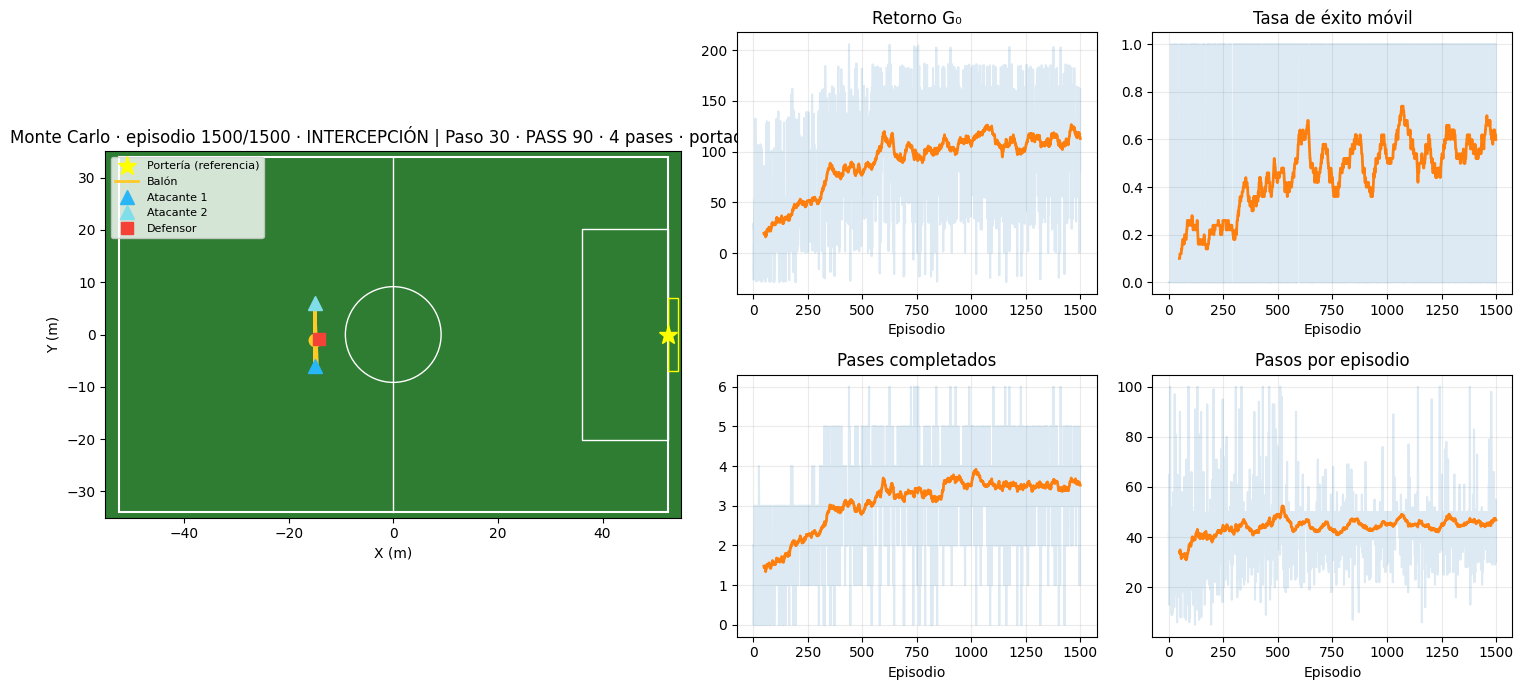

In [28]:
N_EPISODES = 1500
results = {}
for algorithm in ALGORITHMS:
    for epsilon_mode in ("constant", "decay"):
        np.random.seed(42)
        env = PassingPossessionSimEnv()
        options = dict(
            env=env,
            algorithm=algorithm,
            n_episodes=N_EPISODES,
            epsilon_mode=epsilon_mode,
        )
        if algorithm == "mc" and epsilon_mode == "decay":
            Q, history = train_visual(render_every=500, **options)
        else:
            Q, history = TRAINERS[algorithm](
                env=env, n_episodes=N_EPISODES, epsilon_mode=epsilon_mode
            )
        results[(algorithm, epsilon_mode)] = (Q, history)

### 3.1 Varianza y sesgo empírico

La referencia es el retorno medio de los últimos 100 episodios de Q-Learning con exploración decreciente. Es una comparación de rendimientos, no una estimación del sesgo de los objetivos TD.


In [ ]:
# Referencia común: retorno medio de los últimos 100 episodios de Q-Learning.
# El sesgo es la diferencia de medias frente a esta referencia empírica.
window = 100
reference = np.mean(results[("q_learning", "decay")][1]["g0"][-window:])
fig, (ax_bias, ax_variance) = plt.subplots(1, 2, figsize=(13, 4.5))
for algorithm, color in zip(ALGORITHMS, ("#1f77b4", "#d62728", "#2ca02c", "#9467bd")):
    returns = np.asarray(results[(algorithm, "decay")][1]["g0"], dtype=float)
    episodes = np.arange(window, len(returns) + 1)
    mean = np.convolve(returns, np.ones(window) / window, mode="valid")
    variance = pd.Series(returns).rolling(window).var().to_numpy()[window - 1 :]
    ax_bias.plot(
        episodes, mean - reference, label=ALGORITHM_NAMES[algorithm], color=color
    )
    ax_variance.plot(episodes, variance, label=ALGORITHM_NAMES[algorithm], color=color)
ax_bias.axhline(0, color="black", linewidth=0.8)
ax_bias.set_title("Sesgo empírico del retorno")
ax_bias.set_ylabel("Media móvil − referencia final")
ax_variance.set_title("Varianza móvil del retorno")
ax_variance.set_ylabel("Varianza en 100 episodios")
for ax in (ax_bias, ax_variance):
    ax.set_xlabel("Episodio")
    ax.grid(alpha=0.3)
    ax.legend(fontsize=8)
fig.tight_layout()
plt.show()

## 4. Retorno de los cuatro algoritmos

Media móvil del retorno G₀ para Monte Carlo, SARSA, Expected SARSA y Q-Learning, con exploración constante y decreciente.


In [ ]:
def greedy_action(Q, state, rng):
    values = Q.get(state)
    return int(np.argmax(values)) if values is not None else int(rng.integers(7))


fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), sharey=True)
colors = ('#1f77b4', '#d62728', '#2ca02c', '#9467bd')
for ax, epsilon_mode in zip(axes, ('constant', 'decay')):
    for algorithm, color in zip(ALGORITHMS, colors):
        _, history = results[(algorithm, epsilon_mode)]
        average = moving_average(history['g0'])
        ax.plot(range(len(history['g0']) - len(average), len(history['g0'])),
                average, label=ALGORITHM_NAMES[algorithm], color=color)
    ax.set_title(f'Retorno G₀ · ε {epsilon_mode}')
    ax.set_xlabel('Episodio')
    ax.grid(alpha=0.25)
    ax.legend(fontsize=8)
axes[0].set_ylabel('Retorno G₀ (media móvil)')
fig.tight_layout()
plt.show()

## 5. Valor y política en estados observados

Se presenta un corte de la tabla Monte Carlo con exploración decreciente: distancia al balón frente a distancia al defensor. Los otros cuatro componentes se fijan en su combinación más frecuente. Las casillas grises no se observaron y no tienen política aprendida.


In [ ]:
Q_map, history_map = results[("mc", "decay")]
visits = history_map["state_visits"]
fixed_counts = Counter()
for state, count in visits.items():
    fixed_counts[(state[1], state[2], state[3], state[5])] += count
fixed = fixed_counts.most_common(1)[0][0]
values = np.full((4, 4), np.nan)
actions = np.full((4, 4), -1, dtype=int)
for state, count in visits.items():
    if (state[1], state[2], state[3], state[5]) == fixed:
        row, col = state[0], state[4]
        q_values = Q_map[state]
        values[row, col] = q_values.max()
        actions[row, col] = int(np.argmax(q_values))

fig, (ax_value, ax_policy) = plt.subplots(1, 2, figsize=(11, 4.5))
cmap = plt.get_cmap("viridis").copy()
cmap.set_bad("#dddddd")
image = ax_value.imshow(values, cmap=cmap, aspect="auto")
fig.colorbar(image, ax=ax_value, label="V(s) = max Q(s,a)")
ax_value.set_title("Valor de estados observados")
ax_policy.imshow(actions, cmap="tab10", vmin=0, vmax=6, aspect="auto")
ax_policy.set_title("Acción greedy")
for row in range(4):
    for col in range(4):
        if actions[row, col] >= 0:
            ax_policy.text(
                col,
                row,
                ACTION_NAMES[actions[row, col]],
                ha="center",
                va="center",
                fontsize=7,
            )
for ax in (ax_value, ax_policy):
    ax.set_xticks(range(4), ("<5", "5–10", "10–20", ">=20"))
    ax.set_yticks(range(4), ("<=0.8", "0.8–2", "2–4", ">=4"))
    ax.set_xlabel("Distancia al defensor (m)")
    ax.set_ylabel("Distancia al balón (m)")
fig.suptitle(
    f"Ángulo balón, distancia/ángulo compañero y ángulo defensor fijos: {fixed}"
)
fig.tight_layout()
plt.show()

## 6. Trayectoria aleatoria frente a política aprendida

Las dos políticas parten de la misma configuración inicial. Se dibuja la trayectoria completa del balón y se indican el número de pases, pasos y el resultado de cada episodio. La portería sigue siendo solo una referencia espacial.


In [ ]:
np.random.seed(2026)
base_env = PassingPossessionSimEnv()
base_env.reset()
initial_rng_state = np.random.get_state()
Q_compare = results[("mc", "decay")][0]


def run_episode(env, policy, seed=2026):
    rng = np.random.default_rng(seed)
    state = env._get_state()
    for _ in range(env.max_steps):
        action = (
            int(rng.integers(7))
            if policy == "aleatoria"
            else greedy_action(Q_compare, state, rng)
        )
        state, _, done, info = env.step(action)
        if done:
            return info


fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, policy in zip(axes, ("aleatoria", "greedy")):
    np.random.set_state(initial_rng_state)
    env = copy.deepcopy(base_env)
    info = run_episode(env, policy)
    draw_pitch(ax)
    ax.plot(
        env.ball_trajectory_x,
        env.ball_trajectory_y,
        color="#ffca28",
        linewidth=2,
        label="Trayectoria del balón",
    )
    ax.plot(
        env.ball_trajectory_x[0],
        env.ball_trajectory_y[0],
        "o",
        color="white",
        markeredgecolor="black",
        label="Inicio",
    )
    ax.plot(env.ball_x, env.ball_y, "o", color="#ffca28", label="Final")
    for index, player in enumerate(env.attackers):
        ax.plot(
            player["x"], player["y"], "^", markersize=9, label=f"Atacante {index + 1}"
        )
    ax.plot(env.defender_x, env.defender_y, "s", color="#f44336", label="Defensor")
    ax.set_title(
        f"{policy.capitalize()} · {'éxito' if info['success'] else 'sin éxito'} · "
        f"{info['passes']} pases · {info['steps']} pasos"
    )
    ax.legend(fontsize=8)
fig.tight_layout()
plt.show()

## 7. Alcance de RoboCup

Los retornos y tasas anteriores corresponden únicamente a `PassingPossessionSimEnv`. El cliente UDP actual no proporciona todas las observaciones de compañeros y rivales necesarias para ejecutar esta política dentro de `rcssserver`. La ejecución del notebook y las comprobaciones en Docker quedan pendientes.
